# DATASET: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation/data

In [ ]:
import kagglehub
import os
import torch

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path:", path)
path=os.path.join(path,'kaggle_3m')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path: /kaggle/input/lgg-mri-segmentation


# Create dataframe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from torchvision.transforms import functional as F
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import ImageFolder
import tensorflow as tf
import cv2
from PIL import Image
from skimage.transform import resize

In [ ]:
def create_dataset(data_dir):
    images_paths = []
    masks_paths = glob(f'{data_dir}/*/*_mask*')

    for i in masks_paths:
        images_paths.append(i.replace('_mask', ''))


    df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})
    return df


The `create_dataset` function generates a Pandas DataFrame containing paths to images and their corresponding mask images.

In [ ]:
df=create_dataset(path)

# Image example

/tmp/ipykernel_38855/2876311817.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img = cv2.imread(df.iloc[14][0], cv2.IMREAD_UNCHANGED)


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 5, 0],
        [0, 4, 0],
        [0, 2, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 4, 0],
        [0, 4, 0],
        [0, 1, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 5, 0],
        [0, 4, 0],
        [0, 1, 0]]], dtype=uint8)
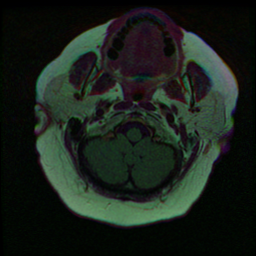

In [ ]:


img = cv2.imread(df.iloc[14][0], cv2.IMREAD_UNCHANGED)
img

# Task 1: classification
First, we need to create labels using images masks

In [ ]:
for i in range(len(df)):
  img = cv2.imread(df.iloc[i][1], cv2.IMREAD_UNCHANGED)
  if np.unique(img).any()>0:
    df.loc[i, 'label'] = 1
  else:
    df.loc[i, 'label'] = 0

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
/tmp/ipykernel_38855/2620155567.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img = cv2.imread(df.iloc[i][1], cv2.IMREAD_UNCHANGED)
/tmp/ipykernel_38855/2620155567.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img = cv2.imread(df.iloc[i][1], cv2.IMREAD_UNCHANGED)
/tmp/ipykernel_38855/2620155567.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img = cv2.i

In [ ]:
df.head()

,images_paths,masks_paths,label
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0.0
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0.0
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.0
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.0
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.0


In [ ]:
X = []
for img_path in df['images_paths']:
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    X.append(img)
y=df['label']

We create dataframe for classification problem

In [ ]:
df_classification = pd.DataFrame(data= {'data': X, 'labels': y})

In [ ]:
df_classification.head()

,data,labels
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0.0
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0.0
2,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1.0
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1.0
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1.0


In [ ]:
train_df,test_df = train_test_split(df_classification, test_size=0.2,stratify=df_classification["labels"], random_state=42)

The dataset is split into training and testing sets, ensuring a stratified split based on the labels to maintain class distribution.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class DataFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_data = self.df.loc[idx, "data"]
        label = self.df.loc[idx, "labels"]
        image_data = cv2.cvtColor(image_data, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image_data.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

This custom `DataFrameDataset` class prepares the data for PyTorch, handling image loading, transformations and label retrieval.

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std  = [0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std  = [0.229, 0.224, 0.225])
])

train_ds = DataFrameDataset(train_df, transform=train_tfms)
test_ds  = DataFrameDataset(test_df,  transform=test_tfms)



train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


This cell defines image transformations for training and testing, including resizing, augmentation, normalization, and then creates DataLoader instances for efficient batch processing.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.batch1=nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3,padding=1)
        self.batch2=nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding=1)
        self.batch3=nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64*32*32, 128)
        self.fc2=nn.Linear(128,2)
        self.flatten=nn.Flatten()
        self.drop=nn.Dropout(0.3)


    def forward(self, x):
        x=torch.relu(self.batch1(self.conv1(x)))
        x=self.pool(x)
        x=torch.relu(self.batch2(self.conv2(x)))
        x=self.pool(x)
        x=torch.relu(self.batch3(self.conv3(x)))
        x=self.pool(x)
        x=self.flatten(x)
        x=torch.relu(self.fc1(x))
        x=self.drop(x)
        x=self.fc2(x)
        return x

The `CNN` class defines a custom Convolutional Neural Network architecture for image classification.

In [ ]:
model=CNN()
criterion =  nn.CrossEntropyLoss()
optimizer_cnn= optim.Adam(model.parameters(), lr=0.001)


This cell initializes the CNN model, defines the Cross Entropy Loss function, and sets up the Adam optimizer.

In [ ]:
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_model(model, trainloader, criterion, optimizer, epochs=5):
    model.to(device)
    progress_bar = tqdm(range(epochs))
    for epoch in progress_bar:

      for batch_index, (data, targets) in enumerate(trainloader):
        data = data.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        scores = model(data)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix({'loss': loss.item()})


print("Trening CNN:")
train_model(model, train_loader, criterion, optimizer_cnn)



Trening CNN:


  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 5/5 [18:41<00:00, 224.26s/it, loss=0.302]


The `train_model` function implements the training loop for the CNN, including forward pass, loss calculation, backpropagation, and optimizer step.

In [ ]:

def evaluate_model(model, testloader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for data, targets in testloader:
        data = data.to(device)
        targets = targets.to(device)
        scores = model(data)
        _, predicted = torch.max(scores.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

      accuracy = 100 * correct / total
      print(f'Accuracy: {accuracy:.2f}%')

evaluate_model(model, test_loader)



Accuracy: 77.23%


# Accuracy = 77,23%

# Transfer Learning

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
            param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


This section implements transfer learning using a pre-trained ResNet50 model. The pre-trained layers are frozen, and a new classification head is added and trained.

In [ ]:
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_model(model, trainloader, criterion, optimizer, epochs=5):
    model.to(device)
    progress_bar = tqdm(range(epochs))
    for epoch in progress_bar:

      for batch_index, (data, targets) in enumerate(trainloader):
        data = data.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        scores = model(data)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix({'loss': loss.item()})


print("Trening CNN:")
train_model(model, train_loader, criterion, optimizer)



Trening CNN:


100%|██████████| 5/5 [1:43:09<00:00, 1237.97s/it, loss=0.234]


This cell trains the ResNet50 model with the new classification head using the defined training loop.

In [ ]:

def evaluate_model(model, testloader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for data, targets in testloader:
        data = data.to(device)
        targets = targets.to(device)
        scores = model(data)
        _, predicted = torch.max(scores.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

evaluate_model(model, test_loader)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 81.93%


This cell evaluates the performance of the ResNet50 transfer learning model on the test set.

# Accuracy = 81,93 %

# Grad-CAM visualization

In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=91dbc90a0089a0153705d4e0c34d586490951c3e1a859db891aaae14f3e3399c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
target_layer = model.conv3
cam = GradCAM(model=model, target_layers=[target_layer])

Initializes the GradCAM object with the model and the target convolutional layer (conv3 from the first CNN model).

In [ ]:
sick_df = df[df['label'] == 1].reset_index(drop=True)

img_pil  = Image.open(sick_df.iloc[0][0]).convert('RGB')
img_vis  = np.array(transforms.Resize((256, 256))(img_pil)).astype('float32') / 255.0
input_tensor = test_tfms(img_pil).unsqueeze(0).to(device)

/tmp/ipykernel_38855/1400289963.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img_pil  = Image.open(sick_df.iloc[0][0]).convert('RGB')


Loads a sample image with a tumor from the `sick_df` DataFrame, converts it to a PIL image, resizes it, and prepares it as an input tensor for the model.

In [ ]:

CLASS_NAMES = ['zdrowy', 'guz']

model.eval()

def predict(model, input_tensor):
    with torch.no_grad():
        logits = model(input_tensor)
        probs  = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    return pred_class, probs.cpu().numpy()[0]

pred_class, probs = predict(model, input_tensor)
print(f"Predykcja: {CLASS_NAMES[pred_class]} | prawdopodobieństwa: zdrowy={probs[0]:.3f}, guz={probs[1]:.3f}")

Predykcja: guz | prawdopodobieństwa: zdrowy=0.176, guz=0.824


The `predict` function uses the trained model to classify the input image and returns the predicted class and probabilities. The result for the sample image is then printed.

In [ ]:
targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
cam_image = show_cam_on_image(img_vis, grayscale_cam, use_rgb=True)

This cell generates the Grad-CAM heatmap for the input image, highlighting regions contributing to the predicted class.

/tmp/ipykernel_38855/1464064045.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.subplot(2,2,2); plt.title("Mask"); plt.imshow(Image.open(sick_df.iloc[0][1])); plt.axis("off")


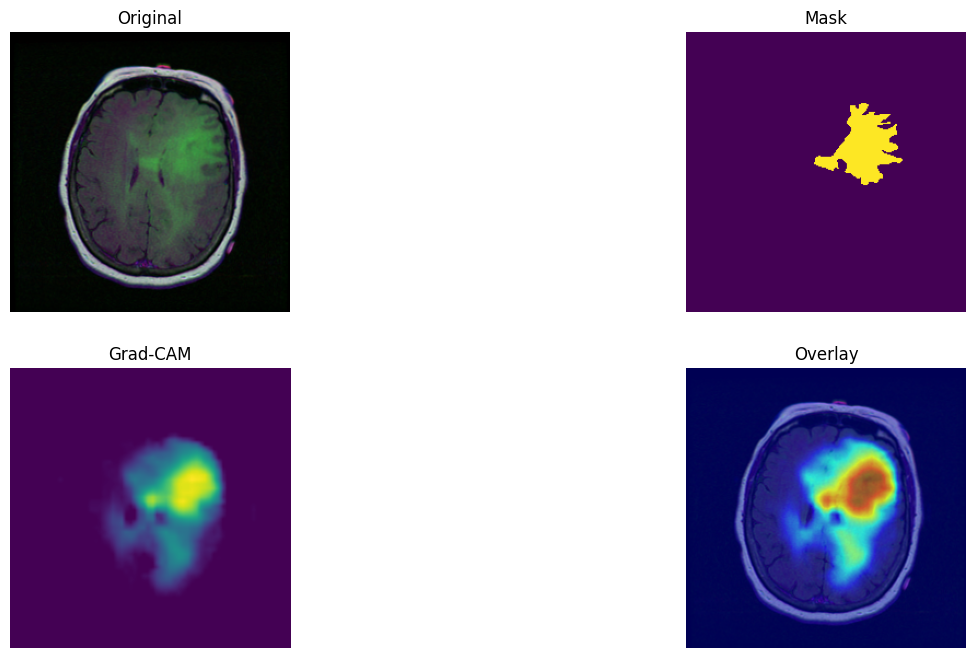

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1); plt.title("Original"); plt.imshow(img_vis); plt.axis("off")
plt.subplot(2,2,2); plt.title("Mask"); plt.imshow(Image.open(sick_df.iloc[0][1])); plt.axis("off")
plt.subplot(2,2,3); plt.title("Grad-CAM"); plt.imshow(grayscale_cam); plt.axis("off")
plt.subplot(2,2,4); plt.title("Overlay"); plt.imshow(cam_image); plt.axis("off")
plt.show()

This cell visualizes the original image, its corresponding mask, the Grad-CAM heatmap and an overlay of the heatmap on the original image.

# Segmentation

(256, 256, 3)
(256, 256)


/tmp/ipykernel_38855/2192295018.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img_example=cv2.imread(df.iloc[2][0], cv2.IMREAD_UNCHANGED)
/tmp/ipykernel_38855/2192295018.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask_example=cv2.imread(df.iloc[2][1], cv2.IMREAD_UNCHANGED)


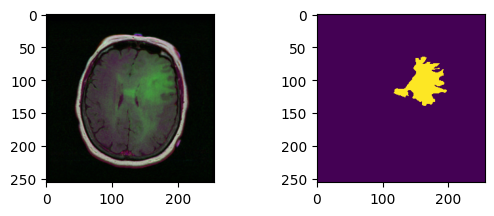

In [ ]:
img_example=cv2.imread(df.iloc[2][0], cv2.IMREAD_UNCHANGED)
mask_example=cv2.imread(df.iloc[2][1], cv2.IMREAD_UNCHANGED)
plt.subplot(2,2,1)
plt.imshow(img_example)
print(img_example.shape)
plt.subplot(2,2,2)
plt.imshow(mask_example)
print(mask_example.shape)

Displays an example image and its mask to illustrate the data structure for the segmentation task.

In [ ]:
def load_image(path, size=(256, 256)):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0
    img = F.to_tensor(img.astype(np.float32))
    return img


def load_mask(path, size=(256, 256)):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.float32)
    mask = F.to_tensor(mask)
    return mask


These helper functions load and preprocess images and masks for the segmentation task, including resizing and normalization.

In [ ]:
print(f"Length of dataframe: {len(df)}")
print(f"Cases with tumor: {(df['label']==1).sum()}")
print(f"Healthy cases: {(df['label']==0).sum()}")

Length of dataframe: 3929
Cases with tumor: 1373
Healthy cases: 2556


This cell provides an overview of the dataset, showing the total number of entries and the count of cases with and without tumors.

In [ ]:
processed_images = []
processed_masks = []
for i in range(len(df)):
  img_path = df.loc[i, 'images_paths']
  mask_path = df.loc[i, 'masks_paths']

  img_process = load_image(img_path)
  mask_process = load_mask(mask_path)

  processed_images.append(img_process)
  processed_masks.append(mask_process)


This loop processes all images and masks in the DataFrame using the `load_image` and `load_mask` functions, storing the preprocessed tensors.

In [ ]:
indices = list(range(len(processed_images)))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.2, random_state=42)

img_train  = [processed_images[i] for i in idx_train]
mask_train = [processed_masks[i]  for i in idx_train]
img_val    = [processed_images[i] for i in idx_val]
mask_val   = [processed_masks[i]  for i in idx_val]
img_test   = [processed_images[i] for i in idx_test]
mask_test  = [processed_masks[i]  for i in idx_test]

The processed image and mask data are split into training, validation, and testing sets for the segmentation model.

In [ ]:

train_loader_seg = DataLoader(TensorDataset(torch.stack(img_train),  torch.stack(mask_train)),
                               batch_size=8, shuffle=True)
val_loader_seg   = DataLoader(TensorDataset(torch.stack(img_val),    torch.stack(mask_val)),
                               batch_size=8, shuffle=False)
test_loader_seg  = DataLoader(TensorDataset(torch.stack(img_test),   torch.stack(mask_test)),
                               batch_size=8, shuffle=False)

This cell creates PyTorch DataLoaders for the training, validation, and test sets, facilitating batch processing during model training and evaluation.

In [ ]:
class UNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder_layers = list(self.encoder.children())
        self.encoder = torch.nn.Sequential(*self.encoder_layers[:-2])

        self.decoder = torch.nn.Sequential(
            torch.nn.Conv2d(512, 256, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(256, 128, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

The `UNet` class defines the architecture for the segmentation model, utilizing a ResNet18 encoder and a custom decoder.

In [ ]:


def compute_iou(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = mask.astype(bool)

    if pred_bin.shape != mask_bin.shape:
        pred_bin = resize(pred_bin.astype(np.float32), mask_bin.shape,
                          order=0, preserve_range=True) > 0.5
    intersection = (pred_bin & mask_bin).sum()
    union        = (pred_bin | mask_bin).sum()
    return float(intersection) / float(union) if union > 0 else 0.0

def compute_dice(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = mask.astype(bool)
    if pred_bin.shape != mask_bin.shape:
        pred_bin = resize(pred_bin.astype(np.float32), mask_bin.shape,
                          order=0, preserve_range=True) > 0.5
    intersection = (pred_bin & mask_bin).sum()
    return float(2 * intersection) / float(pred_bin.sum() + mask_bin.sum() + 1e-8)


These functions calculate Intersection over Union (IoU) and Dice coefficient, common metrics for evaluating segmentation model performance.

In [ ]:
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):

        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, pred, mask):

        pred = pred.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        TP = (pred * mask).sum()
        FN = (mask * (1 - pred)).sum()
        FP = ((1 - mask) * pred).sum()

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
        focal_tversky = (1 - tversky) ** self.gamma

        return focal_tversky

The `FocalTverskyLoss` class implements a custom loss function designed for segmentation tasks, which is particularly effective for imbalanced datasets.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 63.4MB/s]


Epoch [01/5]  Train Loss: 0.5520  Val Loss: 0.4950
Epoch [02/5]  Train Loss: 0.4347  Val Loss: 0.4998
Epoch [03/5]  Train Loss: 0.4194  Val Loss: 0.4527
Epoch [04/5]  Train Loss: 0.3990  Val Loss: 0.4361
Epoch [05/5]  Train Loss: 0.3715  Val Loss: 0.3936


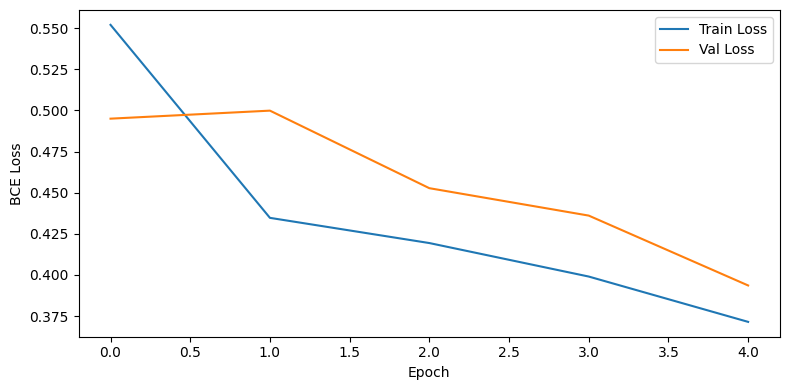

In [ ]:
model_unet = UNet().to(device)
optimizer_unet = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
loss_fn = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)

EPOCHS = 5
unet_losses     = []
unet_val_losses = []

for epoch in range(EPOCHS):

    model_unet.train()
    total_train_loss = 0.0

    for images, masks in train_loader_seg:
        images, masks = images.to(device), masks.to(device)

        preds = model_unet(images)

        if preds.shape != masks.shape:
            preds = nn.functional.interpolate(preds, size=masks.shape[2:],
                                               mode='bilinear', align_corners=False)

        loss = loss_fn(preds, masks)
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        total_train_loss += loss.item()


    avg_train = total_train_loss / len(train_loader_seg)
    unet_losses.append(avg_train)


    model_unet.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader_seg:
            images, masks = images.to(device), masks.to(device)
            preds = model_unet(images)
            if preds.shape != masks.shape:
                preds = nn.functional.interpolate(preds, size=masks.shape[2:],
                                                   mode='bilinear', align_corners=False)
            total_val_loss += loss_fn(preds, masks).item()

    avg_val = total_val_loss / len(val_loader_seg)
    unet_val_losses.append(avg_val)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}")


plt.figure(figsize=(8, 4))
plt.plot(unet_losses,     label='Train Loss')
plt.plot(unet_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')

plt.legend()
plt.tight_layout()
plt.show()

This cell initializes the UNet model, optimizer, and loss function, then trains the model for a specified number of epochs, tracking training and validation losses.

In [ ]:

all_ious, all_dices = [], []
sick_images, sick_masks, sick_preds = [], [], []


with torch.no_grad():
    for images, masks in test_loader_seg:
        images = images.to(device)
        preds  = model_unet(images).cpu().numpy()
        masks_np = masks.numpy()

        for i in range(len(images)):
            p = preds[i][0]
            m = masks_np[i][0]
            all_ious.append(compute_iou(p, m))
            all_dices.append(compute_dice(p, m))

            if masks[i][0].sum() > 0:
                sick_images.append(images[i])
                sick_masks.append(masks[i])
                sick_preds.append(preds[i])



print(f"Average IoU  (test): {np.mean(all_ious):.4f}")
print(f"Average Dice (test): {np.mean(all_dices):.4f}")

Average IoU  (test): 0.1813
Average Dice (test): 0.2225


This cell evaluates the trained UNet model on the test set, calculating and printing the average IoU and Dice scores.

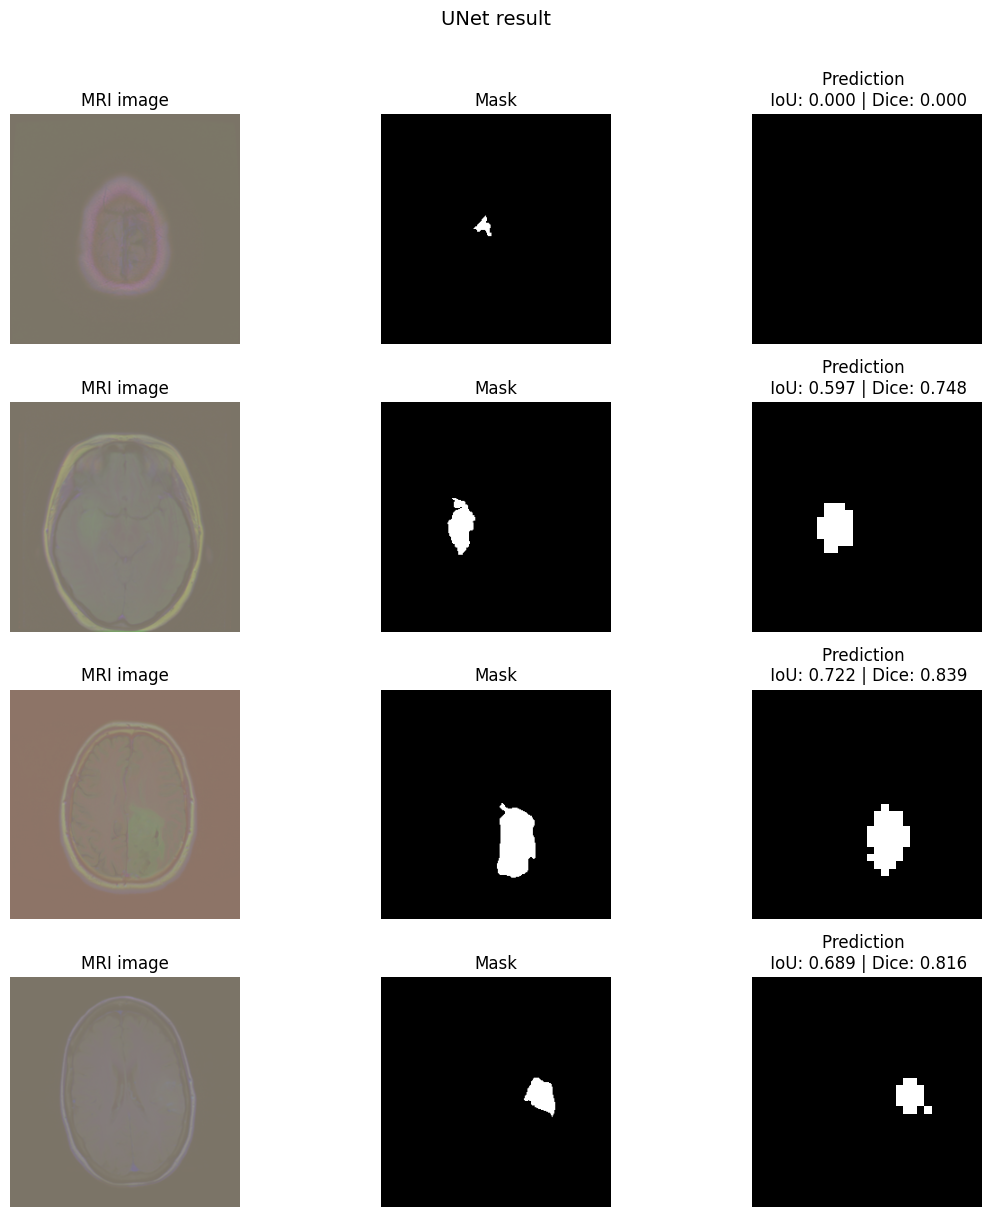

In [ ]:


model_unet.eval()
images_vis, masks_vis = next(iter(test_loader_seg))
images_vis = images_vis.to(device)

with torch.no_grad():
    preds_vis = model_unet(images_vis).cpu().numpy()


mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

n_show = min(4, len(sick_images))
plt.figure(figsize=(12, n_show * 3))

for i in range(n_show):
    img_np   = sick_images[i].numpy().transpose(1, 2, 0)
    img_np   = np.clip(img_np * std + mean, 0, 1)
    mask_np  = sick_masks[i][0].numpy().astype(bool)
    pred_bin = sick_preds[i][0]> 0.5

    iou  = compute_iou(pred_bin, mask_np)
    dice = compute_dice(pred_bin, mask_np)

    plt.subplot(n_show, 3, i * 3 + 1)
    plt.imshow(img_np)
    plt.title("MRI image")
    plt.axis('off')

    plt.subplot(n_show, 3, i * 3 + 2)
    plt.imshow(mask_np, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(n_show, 3, i * 3 + 3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title(f"Prediction \n IoU: {iou:.3f} | Dice: {dice:.3f}")
    plt.axis('off')

plt.suptitle("UNet result", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

This cell visualizes the segmentation results, displaying the original MRI image, the ground truth mask, and the model's predicted mask for several sick cases, along with their IoU and Dice scores.